# Periodic Waveform Generators

All periodic generators produce exactly `round(fs × duration)` samples of a waveform that repeats at `freq` Hz. They follow the shared generator convention: return `(t, signal)` where `t` is the time axis in seconds.

| Function | Description |
| --- | --- |
| `generate_sine` | Pure sinusoid at `freq` Hz. Single spectral component; the reference waveform for all DSP testing. |
| `generate_square` | Naive (non-bandlimited) square wave with 50 % duty cycle. Spectrum: **odd harmonics only** — fundamental + f·3, f·5, f·7, … with 1/n amplitude. Aliased above ~1 kHz at 44.1 kHz. |
| `generate_sawtooth` | Rising-ramp sawtooth, instant reset at each period. Spectrum: **all harmonics** — f·1, f·2, f·3, … with 1/n amplitude. Brightest naive waveform. |
| `generate_triangle` | Piecewise-linear triangle. Spectrum: **odd harmonics only** (like square) but amplitude rolls off as 1/n² — softer, mellower timbre than the square. |
| `generate_multi_tone` | Sum of `len(freqs)` independently phased sines. Useful for multi-frequency test signals and additive synthesis. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import (
    generate_multi_tone,
    generate_sawtooth,
    generate_sine,
    generate_square,
    generate_triangle,
)

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Five waveforms at 440 Hz, showing exactly 2 complete cycles (≈ 4.5 ms).

**2 × 3 grid (one waveform per panel):**
- **Sine:** smooth oscillation; visually sinusoidal; no harmonics beyond the fundamental
- **Square (duty = 0.5):** abrupt transitions between +1 and −1; Gibbs ringing visible at the edges from the finite harmonic series
- **Sawtooth:** linear ramp from −1 to +1 followed by an instant discontinuity; the brightest timbre of the four basic waveforms
- **Triangle:** slopes up and down linearly; rounded corners (no abrupt transitions); mellower than the square despite sharing its odd-harmonic structure
- **Multi-tone (440 + 880 + 1320 Hz):** superposition of three sines; the irregular envelope reflects beating between the components

Each waveform has different spectral content — the visual shape of the time-domain signal is a direct consequence of which harmonics are present and with what amplitude.


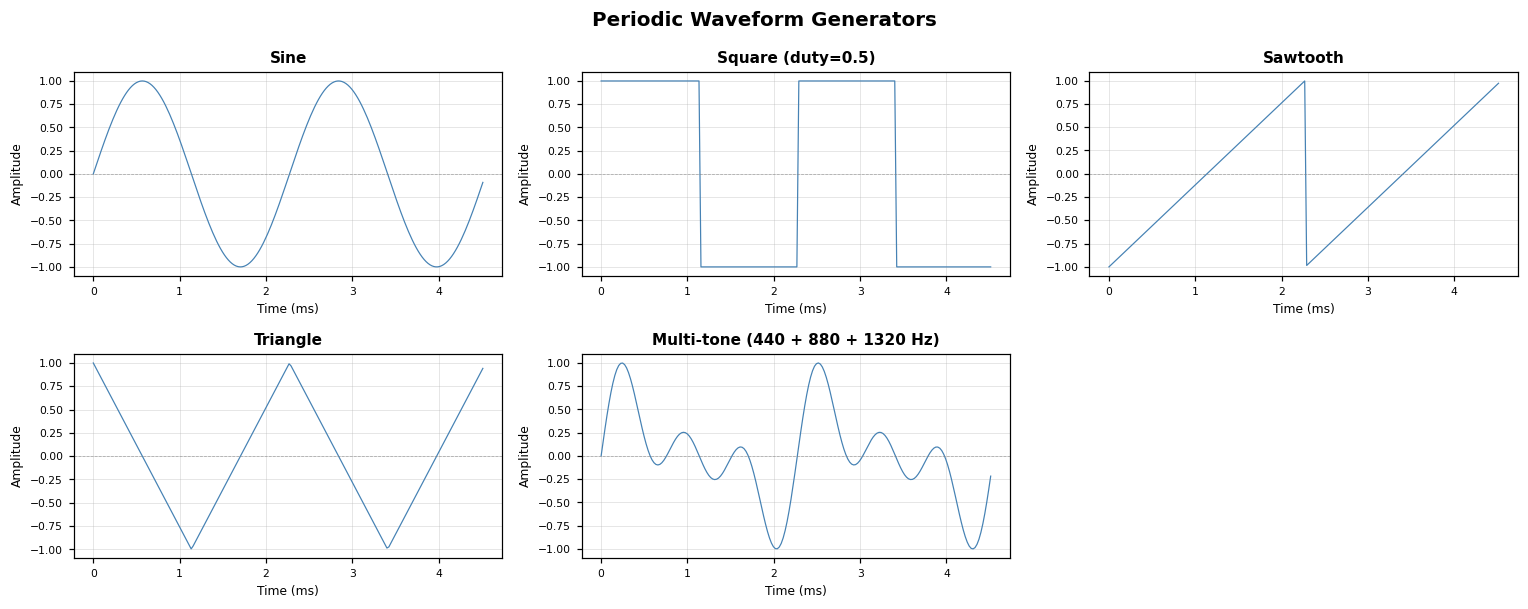

In [2]:
FS = 44100
FREQ = 440.0


def _cycles(freq: float, n: int = 2) -> float:
    return n / freq


PLOTS = [
    {
        "title": "Sine",
        "fn": lambda: generate_sine(freq=FREQ, fs=FS, duration=_cycles(FREQ)),
    },
    {
        "title": "Square (duty=0.5)",
        "fn": lambda: generate_square(freq=FREQ, fs=FS, duration=_cycles(FREQ)),
    },
    {
        "title": "Sawtooth",
        "fn": lambda: generate_sawtooth(freq=FREQ, fs=FS, duration=_cycles(FREQ)),
    },
    {
        "title": "Triangle",
        "fn": lambda: generate_triangle(freq=FREQ, fs=FS, duration=_cycles(FREQ)),
    },
    {
        "title": "Multi-tone (440 + 880 + 1320 Hz)",
        "fn": lambda: generate_multi_tone(freqs=[440.0, 880.0, 1320.0], fs=FS, duration=_cycles(FREQ)),
    },
]

COLS = 3
ROWS = -(-len(PLOTS) // COLS)

fig, axes = plt.subplots(ROWS, COLS, figsize=(14, ROWS * 2.8))
axes = axes.flatten()

for ax, spec in zip(axes, PLOTS):
    t, wave = spec["fn"]()
    ax.plot(t * 1000, wave, linewidth=0.8, color="steelblue")
    ax.set_title(spec["title"], fontsize=10, fontweight="bold")
    ax.set_xlabel("Time (ms)", fontsize=8)
    ax.set_ylabel("Amplitude", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--", alpha=0.6)

for ax in axes[len(PLOTS):]:
    ax.set_visible(False)

fig.suptitle("Periodic Waveform Generators", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()